In [1]:

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
SEED = 42
rng = np.random.default_rng(SEED)

def degree_stats(G):
    deg = np.array([d for _, d in G.degree()], dtype=int)
    mean = deg.mean()
    var = deg.var(ddof=0)
    return deg, mean, var

def degree_distribution(deg):
    k_vals, counts = np.unique(deg, return_counts=True)
    pk = counts / counts.sum()
    return k_vals, pk

def plot_degree_distribution(k, pk, title_prefix=""):
    plt.figure(figsize=(6,4))
    plt.plot(k, pk, marker="o", linestyle="-", markersize=4)
    plt.xlabel("Degree k")
    plt.ylabel("P(k)")
    plt.title(f"{title_prefix}Degree Distribution (linear)")
    plt.grid(True, alpha=0.3)
    plt.show()

    mask = k > 0
    plt.figure(figsize=(6,4))
    plt.loglog(k[mask], pk[mask], marker="o", linestyle="None", markersize=4)
    plt.xlabel("Degree k (log)")
    plt.ylabel("P(k) (log)")
    plt.title(f"{title_prefix}Degree Distribution (log-log)")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

In [3]:
n = 5000
k_avg = 8

p = k_avg / (n - 1)
G_er = nx.erdos_renyi_graph(n=n, p=p, seed=SEED)

deg_er, mean_er, var_er = degree_stats(G_er)
C_er = nx.average_clustering(G_er)

k_er, pk_er = degree_distribution(deg_er)

print("ER G(n,p)")
print("  n:", n)
print("  p:", p)
print("  mean degree:", mean_er)
print("  degree variance:", var_er)
print("  average clustering:", C_er)


ER G(n,p)
  n: 5000
  p: 0.0016003200640128026
  mean degree: 7.8396
  degree variance: 7.937071839999998
  average clustering: 0.0016938165755812815


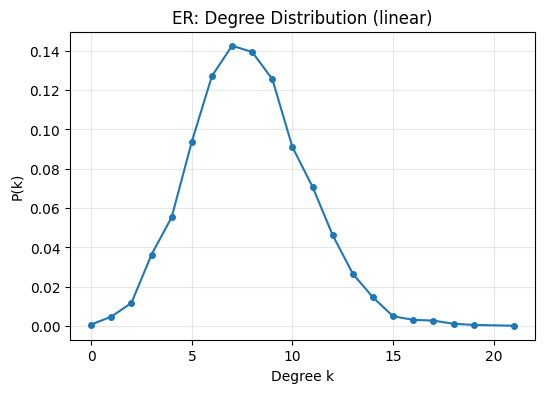

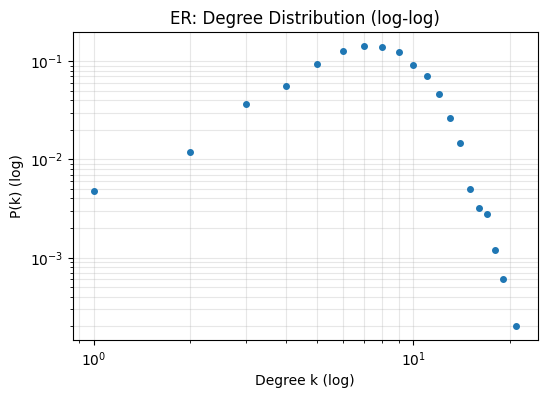

In [4]:
plot_degree_distribution(k_er, pk_er, title_prefix="ER: ")


In [5]:
n = 5000
m = 4

G_ba = nx.barabasi_albert_graph(n=n, m=m, seed=SEED)

deg_ba, mean_ba, var_ba = degree_stats(G_ba)
C_ba = nx.average_clustering(G_ba)

k_ba, pk_ba = degree_distribution(deg_ba)

print("BA (Barabasi-Albert)")
print("  n:", n)
print("  m:", m)
print("  mean degree:", mean_ba)
print("  degree variance:", var_ba)
print("  average clustering:", C_ba)


BA (Barabasi-Albert)
  n: 5000
  m: 4
  mean degree: 7.9936
  degree variance: 103.29915903999999
  average clustering: 0.009860104801723706


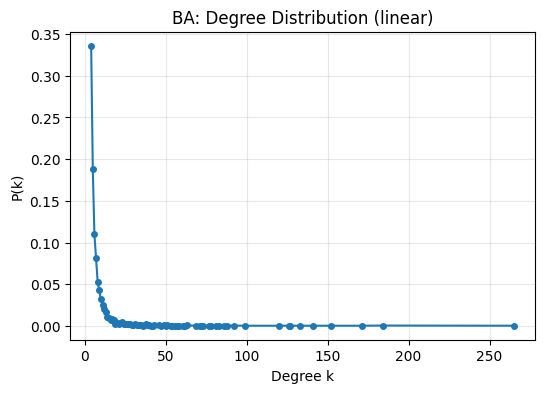

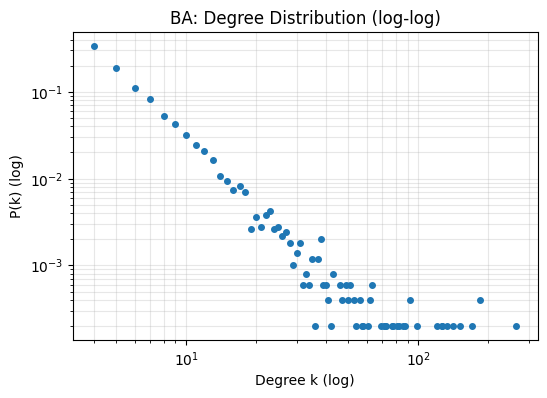

In [6]:
plot_degree_distribution(k_ba, pk_ba, title_prefix="BA: ")


In [7]:
print("Answers:")
print("  Heavy tail behavior: Barabasi-Albert (BA).")
print("  Produces hubs: BA (a few nodes get very large degree).")
print("  Why preferential attachment skews degrees: new nodes link more often to already-high-degree nodes,")
print("  so 'rich get richer' amplifies early advantages into hubs.")
print("  High clustering: neither is typically 'high' at n=5000 with these parameters;")
print("  BA is usually higher than ER, but both are modest compared to clustered social networks.")


Answers:
  Heavy tail behavior: Barabasi-Albert (BA).
  Produces hubs: BA (a few nodes get very large degree).
  Why preferential attachment skews degrees: new nodes link more often to already-high-degree nodes,
  so 'rich get richer' amplifies early advantages into hubs.
  High clustering: neither is typically 'high' at n=5000 with these parameters;
  BA is usually higher than ER, but both are modest compared to clustered social networks.
